<a href="https://colab.research.google.com/github/DarcyAguiar/data_science/blob/master/Analisando_os_Dados_do_Airbnb_Paris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img alt="Colaboratory logo" width="15%" src="https://raw.githubusercontent.com/carlosfab/escola-data-science/master/img/novo_logo_bg_claro.png">

#### **Data Science na Prática 3.0**
*by [sigmoidal.ai](https://sigmoidal.ai)*

---

# Análise dos Dados do Airbnb - Paris

O [Airbnb](https://www.airbnb.com.br/) já é considerado como sendo a **maior empresa hoteleira da atualidade**. Ah, o detalhe é que ele **não possui nenhum hotel**!

Conectando pessoas que querem viajar e se hospedar com anfitriões que querem alugar seus imóveis de maneira prática, o Airbnb fornece uma plataforma inovadora para tornar essa hospedagem alternativa.

No final de 2018, a Startup fundada 10 anos atrás, já havia **hospedado mais de 300 milhões** de pessoas ao redor de todo o mundo, desafiando as redes hoteleiras tradicionais.

Uma das iniciativas do Airbnb é disponibilizar dados do site, para algumas das principais cidades do mundo. Por meio do portal [Inside Airbnb](http://insideairbnb.com/get-the-data.html), é possível baixar uma grande quantidade de dados para desenvolver projetos e soluções de *Data Science*.

Irei analisar os dados referentes à cidade Paris, e ver quais insights podem ser extraídos a partir de dados brutos.

Paris, a capital da França, é uma importante cidade europeia e um centro mundial de arte, moda, gastronomia e cultura. Com tantas atrações turisticas, é uma das capitais mais desejáveis para visitar. 

Esse fato me despertou curiosidade em analisar a cidade.

<center><img alt="Analisando Airbnb" width="50%" src="http://estatidados.com.br/wp-content/uploads/2021/02/1_By3thizRlCxmxPjrzQ8Cug.png"></center>



## Obtenção dos Dados

Os dados usados aqui foram obtidos a partir do site [Inside Airbnb](http://insideairbnb.com/get-the-data.html). Serão utilizados dados que a própria Airbnb disponibliza por meio do portal Inside Airbnb, como incentivo ao desenvolvimento de projetos e soluções de Data Science.

O objetivo dessa analise é gerar informações que auxiliem viajantes a se hospedarem em paris, visando responder as questões como o preço médio de uma diária, média de noites alugadas e tipo de imovel mais alugado.

Dentre os arquivos fornecidos, vamos trabalhar apenas com este:

* `listings.csv` - *Summary information and metrics for listings in Paris (good for visualisations).*

In [42]:
# importar os pacotes necessarios
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [43]:
# importar o arquivo listings.csv para um DataFrame
df = pd.read_csv('https://raw.githubusercontent.com/DarcyAguiar/data_science/master/Paris%2C%20%C3%8Ele-de-France%2C%20France.csv')

## Análise dos Dados

Inicialmente, vamos analisar os dados obtidos para entender sua estrutura e observar o cenário geral das informações.


### **Atributos (variáveis) e tipos das variáveis**

Vamos identificar a quantidade de entradas e variáveis que nosso conjunto de dados possui, ver os tipos de cada coluna e posteriormente verificar as cinco primeiras entradas.

In [44]:
# identificar o volume de dados do DataFrame
print('Entradas:{}'.format(df.shape[0]))
print('Variáveis:{}\n'.format(df.shape[1]))
print('Tipo das Variáveis:\n{}'.format(df.dtypes))
# verificar as 5 primeiras entradas do dataset
df.head()


Entradas:49255
Variáveis:18

Tipo das Variáveis:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group               float64
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                            object
dtype: object


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,5396,Explore the heart of old Paris,7903,Borzou,NaN,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,80,2,277,2022-01-04,1.82,1,66,45,7510402838018
1,7397,MARAIS - 2ROOMS APT - 2/4 PEOPLE,2626,Franck,NaN,Hôtel-de-Ville,48.85909,2.35315,Entire home/apt,105,10,290,2021-12-30,2.21,4,212,20,7510400829623
2,7964,Large & sunny flat with balcony !,22155,Anaïs,NaN,Opéra,48.87417,2.34245,Entire home/apt,130,6,6,2015-09-14,0.04,1,365,0,7510903576564
3,9359,"Cozy, Central Paris: WALK or VELIB EVERYWHERE !",28422,Bernadette,NaN,Louvre,48.86006,2.34863,Entire home/apt,75,180,0,NaN,NaN,1,148,0,"Available with a mobility lease only (""bail mo..."
4,9952,Paris petit coin douillet,33534,Elisabeth,NaN,Popincourt,48.86373,2.37093,Entire home/apt,80,4,34,2021-12-28,0.32,1,212,8,7511101582862


**Dicionário das variáveis**

* *id* - número gerado para identificar o imovel
* *name* - nome do local alugado
* *host_id* - número gereado para identificar proprietário do local
* *host_name* - nome do proprietário do imóvel
* *neighbourhood_group* - Esta coluna não está preenchida
* *neighbourhood* - bairro onde está localizado o imóvel
* *latitude/longitude* - coordenada do imóvel
* *room_type* - tipo de quarto
* *price* - preço do aluguel do imóvel 
* *minimum_nights* - quantidade mínima de noites para reserva 
* *number_of_reviews* - quantidade de reviews que o imóvel possui
* *last_review* - ultimo review do imóvel
* *reviews_per_month* - reviews por mês
* *calculated_host_listings_count* - quantidade de imóveis do mesmo proprietário
* *availability_365* - número de dias diponiveis em um ano
* *number_of_reviews_ltm* - numero de reviews nos últimos 12 meses
* *license* - contrato de arrendamento


### **Porcentagem de valores ausentes no *dataset***
Ao analisar esse dataset podemos ver que algumas variáveis estão com valores ausentes e a variável `minimum_nights` apresenta um valor descrepante de 180 no `id` 3, iremos então fazer uma analise mais detalhada para sabermos como tratar esses dados.



In [45]:
# ordenando em ordem decrescente as variáveis por seus valores ausentes
(df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)


neighbourhood_group               100.000000
license                            42.793625
reviews_per_month                  20.818191
last_review                        20.818191
name                                0.087301
host_name                           0.056847
number_of_reviews                   0.000000
number_of_reviews_ltm               0.000000
availability_365                    0.000000
calculated_host_listings_count      0.000000
id                                  0.000000
minimum_nights                      0.000000
room_type                           0.000000
longitude                           0.000000
latitude                            0.000000
neighbourhood                       0.000000
host_id                             0.000000
price                               0.000000
dtype: float64




* Podemos ver que a coluna `neighbourhood_group` possui 100% dos seus valores faltantes.
* A coluna `license` possui valores ausentes em quase metade das linhas
*As variáveis `reviews_per_month` e `last_review` tem aproximadamente 20% dos 
valores ausentes.


### **Qual o tipo de distribuição das variáveis?** 

Para identificar a distribuição das variáveis numéricas, irei plotar o histograma.

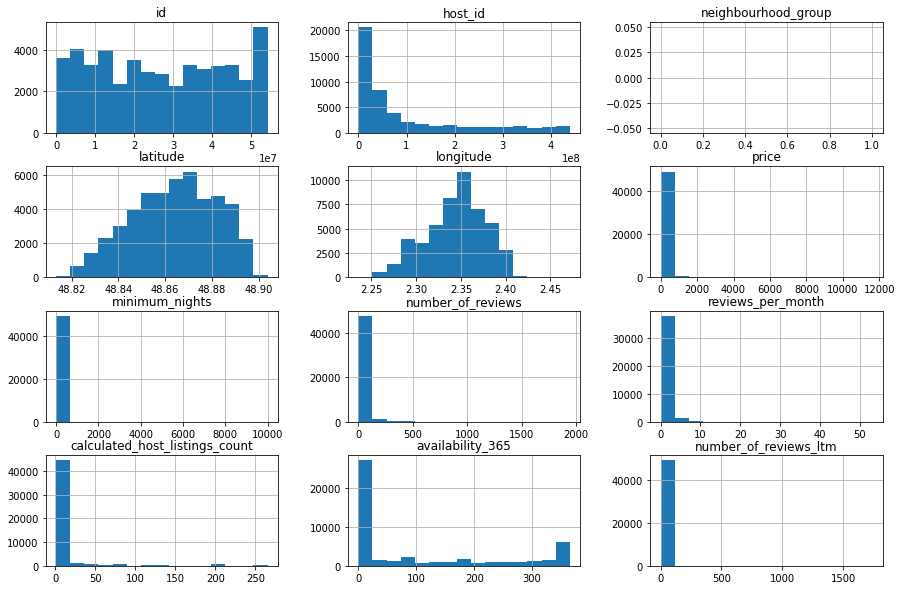

In [46]:
# plotar o histograma das variáveis numéricas
df.hist(bins=15, figsize=(15,10));

### ***Outliers* presentes**
Pelo que podemos ver no histograma, as variáveis `minimum_nights` e `price` tem indícios de *outliers*, pois os valores distorcem a representação do histograma. Podemos utilizar o método `describre` e o grafico boxplot para nos auxiliar na detecção de `outliers`

* Resumo estatístico por meio do método `describe()`
* Plotar `boxplots` para a variável.

In [47]:
#Para vermos o resumo estatístico das variáveis numéricas
df[['price', 'minimum_nights', ]].describe()

,price,minimum_nights
count,49255.000000,49255.000000
mean,128.662958,107.989524
std,228.886467,168.112081
min,0.000000,1.000000
25%,60.000000,2.000000
50%,90.000000,4.000000
75%,135.000000,365.000000
max,11600.000000,9999.000000



Com o resumo estatístico acima, podemos confirmar algumas hipóteses como: 

* A variável *price* possui outliers pois os percentis de 25, 50 e 75 estão bem próximos, diferente da máxima que chega ao valor de €11.600 e a média está dando um valor de €128.
* Já a variável *minimum_nights* possui valores discrepantes, pois 50% dos dados é o que vale a 4 noites e 75% dos dados indica que os quartos são alugados por 365 noites.





#### Identificando Outliers
Vamos utilizar o IQR Score para examinar a dispersão dos dados e identificar os potenciais outliers  e posteriormente plotar boxplot para visualizarmos graficamente os limites desse conjunto




#### IQR Score para price


In [48]:
# identificando os outliers para a variável price
q1_price = df.price.quantile(.25)
q3_price = df.price.quantile(.75)
IQR_price = q3_price - q1_price
print('IQR da variável price: ', IQR_price)

# definindo os limites                                       
sup_price = q3_price + 1.5 * IQR_price
inf_price = q1_price - 1.5 * IQR_price

print('Limite superior de price: ', sup_price)
print('Limite inferior de price: ', inf_price)

IQR da variável price:  75.0
Limite superior de price:  247.5
Limite inferior de price:  -52.5


Aqui podemos ver que temos outliers na parte inferior que precisam ser tratados.

Vamos plotar um boxplot para visualizarmos a diferença feita pela limpeza.

#### IQR Score para minimum_nights

In [49]:
# identificando os outliers para a variável minimum_nights
q1_minimum_nights = df.minimum_nights.quantile(.25)
q3_minimum_nights = df.minimum_nights.quantile(.75)
IQR_minimum_nights = q3_minimum_nights - q1_minimum_nights
print('IQR da variável minimum_nights: ', IQR_minimum_nights)

# definindo os limites                                       
sup_minimum_nights = q3_minimum_nights + 1.5 * IQR_minimum_nights
inf_minimum_nights = q1_minimum_nights - 1.5 * IQR_minimum_nights

print('Limite superior de minimum_nights: ', sup_minimum_nights)
print('Limite inferior de minimum_nights: ', inf_minimum_nights)

IQR da variável minimum_nights:  363.0
Limite superior de minimum_nights:  909.5
Limite inferior de minimum_nights:  -542.5


Podemos ver que utilizando esse método de análise para a variável minimum_nights, percebemos que os valores limites estão muito fora da realidade, então irei plotar o Boxplot para analisarmos com mais detalhes.



#### Boxplot para price

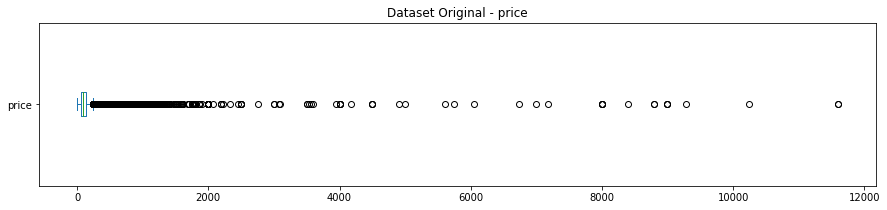

price: valores acima de 247.5
4116 entradas
8.36%


In [50]:
#price
fig, ax = plt.subplots(figsize=(15,3))
df.price.plot(kind='box', vert=False);
ax.set_title('Dataset Original - price')
plt.show()

#ver quantidade de valores acima de 247.5 para price
print('price: valores acima de 247.5')
print('{} entradas'.format(len(df[df.price > 247.5])))
print("{:.3}%".format((len(df[df.price > 247.5]) / df.shape[0])*100))

Pesquisando hospedagem na cidade de Paris no site do Airbnb , podemos ver que o preço médio por noite é de €200 dependendo da região variando pra mais ou pra menos sendo considerado todos os dados informados sem ser feito limpeza, com isso irei fazer uma limpeza dos dados excluindo valores acima de €247,5 que representa 8.36% dos dados desse dataset.  

#### Boxplot para minimum_nights

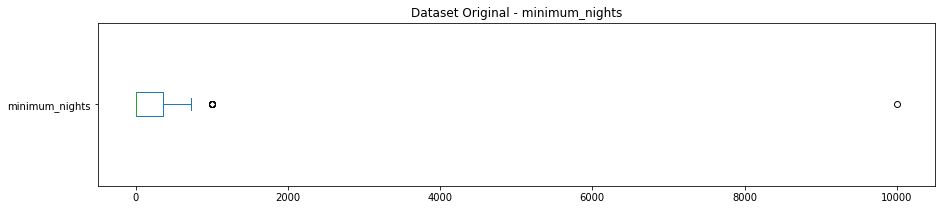

minimum_nights: valores acima de 8:
18122 entradas
36.8%


In [51]:
fig, ax = plt.subplots(figsize=(15,3))
df.minimum_nights.plot(kind='box', vert=False);
ax.set_title('Dataset Original - minimum_nights')
plt.show()

#ver quantidade de valores acima de 8 dias para minimum_nights
print("minimum_nights: valores acima de 8:")
print("{} entradas".format(len(df[df.minimum_nights > 8])))

print("{:.3}%".format((len(df[df.minimum_nights > 8]) / df.shape[0])*100))


Podemos ver que nesse dataset 36,8% das entradas acima de 8 dias da variável `minimum_nigths` estão enviesando consideravelmente o resultado da nossa analise. Decidi fazer a limpeza considerando 8 dias após pesquisar no google indicações de lugares para visitar em Paris e algumas publicações mostravam roteiros de até uma semana e li também no site https://abrir.link/CEtZe onde um anfritião diz que aluga quartos de sua em casa média entre 4 a 8 dias na cidade de São Paulo no Brasil.

#### Histogramas sem *outliers*

Como identificamos *outliers* nas variáveis `price` e `minimum_nights`, vamos limpar o *DataFrame* e plotar novamente.

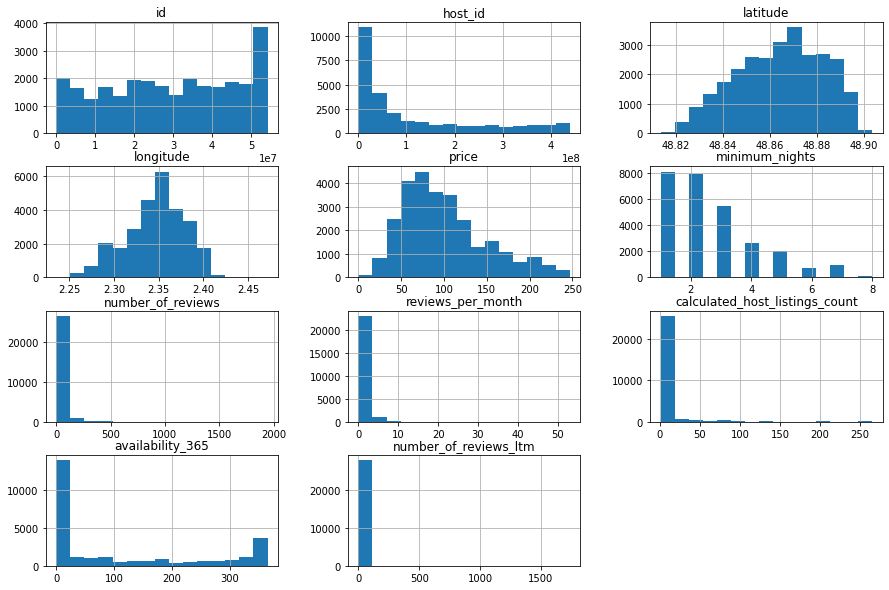

In [52]:
# remover os outliers e passar para um novo DataFrame
df_clean = df.copy()
df_clean.drop(df_clean[df_clean.price > 247.5].index, axis=0, inplace=True)
df_clean.drop(df_clean[df_clean.minimum_nights > 8].index, axis=0, inplace=True)

#remover coluna neighbourhood_group, pois está vazio
df_clean.drop('neighbourhood_group', axis=1, inplace=True)

#Plotar histograma
df_clean.hist(bins=15, figsize=(15,10));

#### Bloxplot sem *outliers*

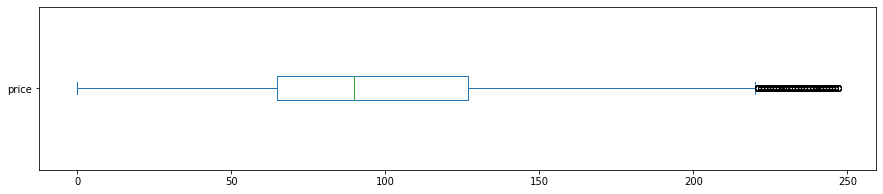

price: valores acima de 247.5
0 entradas
0.0000%


In [53]:
#price
df_clean.price.plot(kind='box', vert=False, figsize=(15, 3))
plt.show()

#ver quantidade de valores acima de 247.5 para price
print('price: valores acima de 247.5')
print('{} entradas'.format(len(df_clean[df_clean.price > 247.5])))
print("{:.4f}%".format((len(df_clean[df_clean.price > 247.5]) / df_clean.shape[0])))

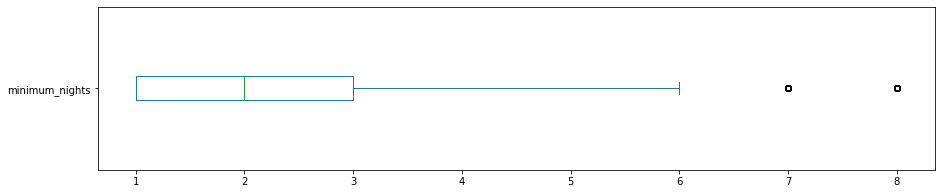

minimum_nights: valores acima de 8:
0 entradas
0.0%


In [54]:
#minimum_nights
df_clean.minimum_nights.plot(kind='box', vert=False, figsize=(15, 3))
plt.show()

#ver quantidade de valores acima de 8 dias para minimum_nights
print("minimum_nights: valores acima de 8:")
print("{} entradas".format(len(df_clean[df_clean.minimum_nights > 8])))
print("{:.4}%".format((len(df_clean[df_clean.minimum_nights > 8]) / df_clean.shape[0])*100))

### **A média dos preços de aluguel e mínimo de noites**


In [55]:
# ver a média da coluna `price``
print('a média dos preços de aluguel é: €{:.2f}'.format(df_clean.price.mean()))
print('A média do minimo de noites para aluguel é: {:.2f}'.format(df_clean.minimum_nights.mean()))

a média dos preços de aluguel é: €100.27
A média do minimo de noites para aluguel é: 2.61


### **Correlação existente entre as variáveis**

É interesante analisar se existe uma relação, por exemplo, entre os preços de aluguel e o tempo de ocupação mínimo. 

Para identificar correlações entre essas variáveis de maior interesse, geramos um mapa de calor ou *heatmap*, com base numa matriz de correlação:

In [56]:
# criar uma matriz de correlação
corr = df_clean[['price','minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']].corr()

# mostrar a matriz de correlação
display(corr)


,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,-0.010758,0.019070,0.059471,0.160382,0.324846
minimum_nights,-0.010758,1.000000,-0.047253,-0.219458,-0.116385,-0.169623
number_of_reviews,0.019070,-0.047253,1.000000,0.587159,-0.017183,0.144798
reviews_per_month,0.059471,-0.219458,0.587159,1.000000,0.101546,0.284796
calculated_host_listings_count,0.160382,-0.116385,-0.017183,0.101546,1.000000,0.217813
availability_365,0.324846,-0.169623,0.144798,0.284796,0.217813,1.000000


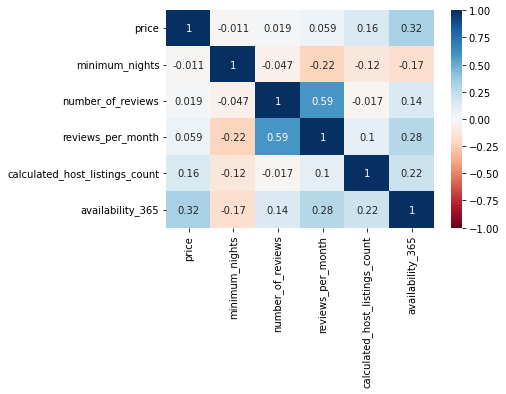

In [57]:
# plotar um heatmap a partir das correlações
sns.heatmap(corr, cmap='RdBu', annot=True, vmin=-1, vmax=1);

Neste caso não verificamos uma correlação entre essas variáveis, a não ser entre `number_of_reviews` e `reviews_per_month`.

### **Tipo de imóvel mais alugado no Airbnb**
A coluna `room_type` indica o tipo de locação. O imóvel mais alugado no Airbnb é *casa/apartamento*, seguindo dos *quartos individuais*, *quarto de hotel* e por ultimo *quartos compartilhados*. Usaremos abaixo o método `velue_counts()` para contarmos a quantidade de ocorrências de cada tipo de aluguel. 



In [58]:
# mostrar a quantidade de cada tipo de imóvel disponível
df_clean.room_type.value_counts() 


Entire home/apt    20374
Private room        6323
Hotel room           808
Shared room          299
Name: room_type, dtype: int64

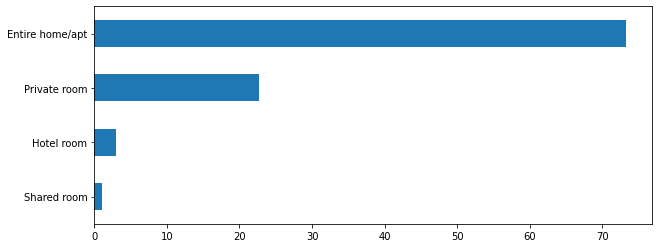

In [59]:
# mostrar a porcentagem de cada tipo de imóvel disponível
(df_clean.room_type.value_counts(ascending = True) / df_clean.shape[0] * 100).plot(kind='barh', figsize=(10,4));

Portanto, dentre os imóveis para alugar são, aproximadamente:
* 72% casas ou apartamentos inteiros
* 22% quartos individuais
* 3% quartos de hotéis
* 1% quartos compartilhados


### **Localidades e valores**

Chegamos ao principal ponto neste breve estudo, que é saber os preços e as disponibilidades de imóveis por bairro. 

Primeiro listaremos os preços médios de cada localidade:


In [60]:
# ver preços por bairros, na média
df_clean.groupby(['neighbourhood']).price.mean().sort_values(ascending=False)

neighbourhood
Louvre                 131.335548
Élysée                 130.199708
Hôtel-de-Ville         126.883495
Temple                 124.526772
Palais-Bourbon         121.597015
Luxembourg             120.686659
Bourse                 120.260954
Panthéon               117.259858
Passy                  115.062333
Opéra                  113.218398
Batignolles-Monceau     99.672836
Vaugirard               98.054106
Entrepôt                96.692701
Popincourt              93.590530
Observatoire            89.150977
Reuilly                 88.836653
Buttes-Montmartre       87.751466
Gobelins                84.514071
Buttes-Chaumont         75.621981
Ménilmontant            75.178332
Name: price, dtype: float64

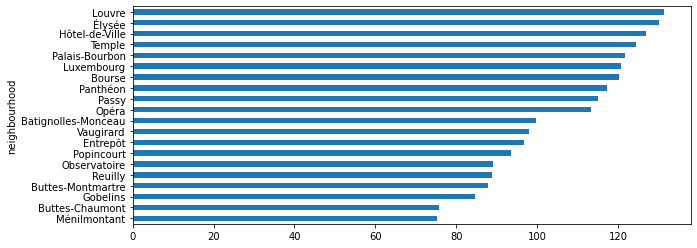

In [61]:
df_clean.groupby(['neighbourhood']).price.mean().sort_values(ascending=True).plot(kind='barh', figsize=(10,4));

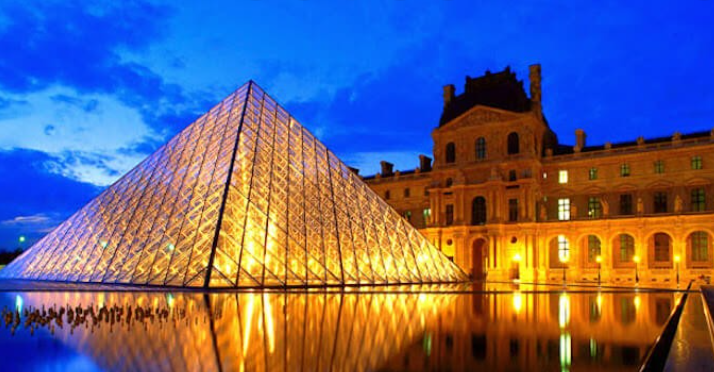



Como podemos ver a localidade com aluguel médio mais alto é as redondezas de Louvre, o que é compatível com a realidade, pois fica localizado no centro de Paris, com diversos pontos turisticos e lojas luxuosas.

O Museu do Louvre é o maior museu de arte do mundo e um monumento histórico em Paris, França. Um marco central da cidade, está localizado na margem direita do rio Sena, no 1º bairro da cidade.

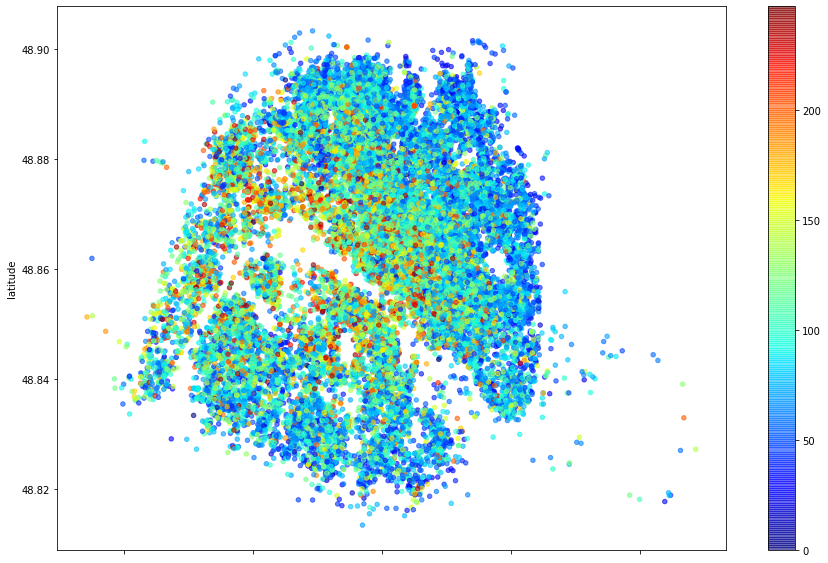

In [62]:
# plotar os imóveis pela latitude-longitude
df_clean.plot.scatter(y='latitude', x='longitude', c=df_clean['price'], cmap=plt.get_cmap('jet'),  alpha=0.6, figsize=(15,10));

Os valores mais altos estão concentrados nos bairros centrais. Mesmo assim podemos notar pontos de valores mais baixos de maneira bem espalhada nessas mesmas regiões.

Do majestoso Louvre ao magnificente Palais-Royal, o bairro é um luxo. Os grandes arcos da Rue de Rivoli são acompanhados por mosaicos em frente a hotéis e vitrines decorados. A Place Vendôme é repleta de vitrines reluzentes dos melhores joalheiros do mundo. Você pode passar horas olhando as lojas de alta-costura ou saboreando uma refeição em um dos restaurantes finos. Depois de todos esses prazeres, os Jardins de Tuileries permitem um digno descanso, enquanto teatros competem pelo seu aplauso. Admiradores do mundo todo procuram esse bairro atraídos pela vida luxuosa de Paris.

## Conclusões


Foi realizado uma análise exploratória superficial na base de dados do Airbnb da cidade de Paris na França, onde foi identificado e tratado outliers em suas variáveis.

Foi observado que 72% das locações oferecidas é referente a casas e apartamentos inteiros e os valores estão na faixa média de €100.27 com a média do dataset de no minimo duas noites para aluguel. Nessa análise podemos notar também que o bairro Louvre tem o preço do aluguel com a maior média mesmo não sendo uma região com bastante quantidade de imóveis para locação em comparação com outros bairros, mas pelo fato de ser bem localizado no centro de Paris com diversas atrações turísticas e lojas de luxos em sua volta o preço dos imóveis se elevam.

Por fim, vale lembrar que este dataset é uma versão resumida de 07 de dezembro de 2021, sendo o ideal para uma abordagem inicial de análise. Para uma análise exploratória mais profunda recomenda-se que seja realizado em um dataset completo